Import Libraries

In [5]:
# Import Libraries
# Importing Numpy & Pandas for data processing & data wrangling
import numpy as np
import pandas as pd

# Importing  tools for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import evaluation metric libraries
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

# Library used for data preprocessing
from sklearn.preprocessing import LabelEncoder

# Import model selection libraries
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, RepeatedStratifiedKFold

# Library used for ML Model implementation
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

# Library used for ignore warnings
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
     

Dataset Loading

In [6]:
# Load Dataset
df = pd.read_csv("iris.csv")

Dataset First View

In [7]:

# Dataset First Look
# View top 5 rows of the dataset
df.head()
     

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5,3.6,1.4,0.2,Iris-setosa


Dataset Rows & Columns count

In [8]:
# Dataset Rows & Columns count
# Checking number of rows and columns of the dataset using shape
print("Number of rows are: ",df.shape[0])
print("Number of columns are: ",df.shape[1])
     

Number of rows are:  302
Number of columns are:  5


Dataset Information

In [9]:
# Dataset Info
# Checking information about the dataset using info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sepal_length  302 non-null    object
 1   sepal_width   301 non-null    object
 2   petal_length  301 non-null    object
 3   petal_width   301 non-null    object
 4   species       301 non-null    object
dtypes: object(5)
memory usage: 11.9+ KB


Duplicate Values

In [10]:
# Dataset Duplicate Value Count
dup = df.duplicated().sum()
print(f'number of duplicated rows are {dup}')
     

number of duplicated rows are 153


Missing Values/Null Values

In [11]:

# Missing Values/Null Values Count
df.isnull().sum()

sepal_length    0
sepal_width     1
petal_length    1
petal_width     1
species         1
dtype: int64

2. Understanding The Variables

In [12]:

# Dataset Columns
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [13]:
# Dataset Describe (all columns included)
df.describe(include= 'all').round(2)
     

,sepal_length,sepal_width,petal_length,petal_width,species
count,302,301,301,301,301
unique,37,24,44,23,4
top,5,3,1.5,0.2,Iris-setosa
freq,20,52,28,56,100


Check Unique Values for each variable.

In [14]:
# Check Unique Values for each variable.
for i in df.columns.tolist():
  print("No. of unique values in",i,"is",df[i].nunique())

No. of unique values in sepal_length is 37
No. of unique values in sepal_width is 24
No. of unique values in petal_length is 44
No. of unique values in petal_width is 23
No. of unique values in species is 4


In [15]:
# We don't need the 1st column so let's drop that
data=df.iloc[:,1:]
     

In [16]:

# New updated dataset
data.head()

,sepal_width,petal_length,petal_width,species
0,3.5,1.4,0.2,Iris-setosa
1,3,1.4,0.2,Iris-setosa
2,3.2,1.3,0.2,Iris-setosa
3,3.1,1.5,0.2,Iris-setosa
4,3.6,1.4,0.2,Iris-setosa


What all manipulations have i done?
Only drop the first column of the dataset.

In [17]:


print(data.columns)
print(data.head())

Index(['sepal_width', 'petal_length', 'petal_width', 'species'], dtype='object')
  sepal_width petal_length petal_width      species
0         3.5          1.4         0.2  Iris-setosa
1           3          1.4         0.2  Iris-setosa
2         3.2          1.3         0.2  Iris-setosa
3         3.1          1.5         0.2  Iris-setosa
4         3.6          1.4         0.2  Iris-setosa


4. Data Vizualization, Storytelling & Experimenting with charts :
==================================================

Understand the relationships between variables
Chart - 1 : Distribution of Numerical Variables

In [22]:
data.columns = data.columns.str.strip()\
                           .str.lower()\
                           .str.replace(' ', '_')\
                           .str.replace('(', '')\
                           .str.replace(')', '')

In [23]:
# Sepal Length vs Sepal Width

# Define colors for each species and the corresponding species labels.
colors = ['red', 'yellow', 'green']
species = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

In [29]:
print(data.columns)

Index(['sepal_width', 'petal_length', 'petal_width', 'species'], dtype='object')


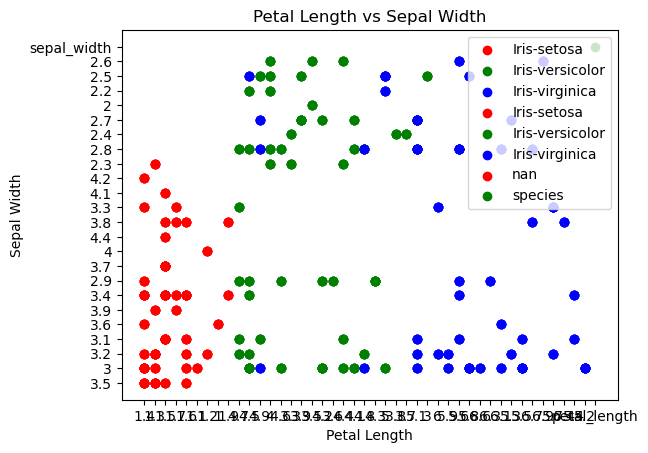

In [31]:
# Chart - 2 Scatter plot visualization code for Sepal Length vs Sepal Width.
# Create a scatter plot for Sepal Length vs Sepal Width for each species.
import matplotlib.pyplot as plt

species_list = data['species'].unique()
colors = ['red', 'green', 'blue']

for i in range(len(species_list)):
    x = data[data['species'] == species_list[i]]
    
    plt.scatter(
        x['petal_length'],
        x['sepal_width'],
        c=colors[i % len(colors)],   # ✅ FIX HERE
        label=species_list[i]
    )

plt.xlabel('Petal Length')
plt.ylabel('Sepal Width')
plt.title('Petal Length vs Sepal Width')
plt.legend()
plt.show()

 Petal Length vs Petal Width

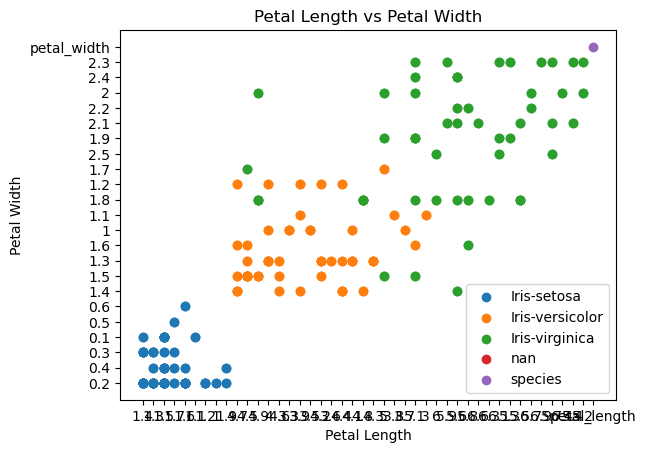

In [35]:
#  Scatter plot visualization code for Petal Length vs Petal Width.
# Create a scatter plot for Petal Length vs Petal Width for each species.
import matplotlib.pyplot as plt

species_list = data['species'].unique()

for sp in species_list:
    x = data[data['species'] == sp]
    
    plt.scatter(
        x['petal_length'],
        x['petal_width'],
        label=sp
    )

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Petal Length vs Petal Width')
plt.legend()
plt.show()
     

Sepal Length vs Petal Length

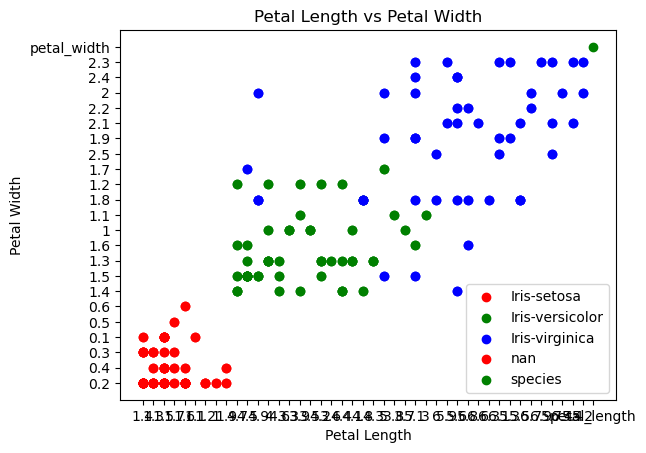

In [39]:
# Chart - 4 Scatter plot visualization code for Sepal Length vs Petal Length.
# Create a scatter plot for Sepal Length vs Petal Length for each species.


species_list = data['species'].unique()
colors = ['red', 'green', 'blue']

for i in range(len(species_list)):
    x = data[data['species'] == species_list[i]]
    
    plt.scatter(
        x['petal_length'],     # ✅ correct
        x['petal_width'],      # ✅ correct
        c=colors[i % len(colors)],
        label=species_list[i]
    )

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Petal Length vs Petal Width')
plt.legend()
plt.show()
     

Sepal Width vs Petal Width

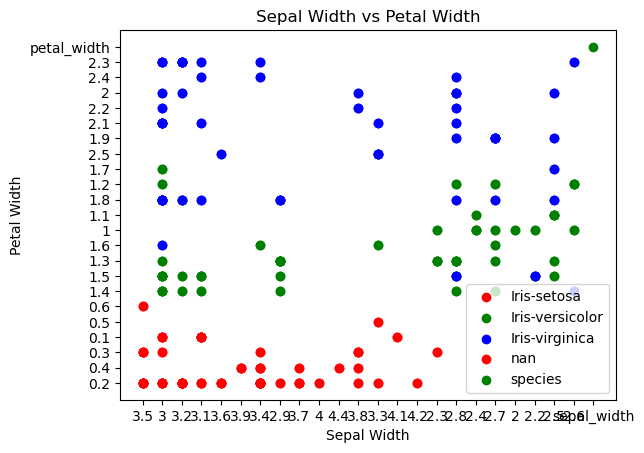

In [43]:
# Chart - 5 Scatter plot visualization code for Sepal Width vs Petal Width.
# Create a scatter plot for Sepal Width vs Petal Width for each species.
import matplotlib.pyplot as plt

species_list = data['species'].unique()
colors = ['red', 'green', 'blue']

for i in range(len(species_list)):
    x = data[data['species'] == species_list[i]]
    
    plt.scatter(
        x['sepal_width'],    # ✅ correct
        x['petal_width'],    # ✅ correct
        c=colors[i % len(colors)],   # avoids index error
        label=species_list[i]
    )

plt.xlabel('Sepal Width')
plt.ylabel('Petal Width')
plt.title('Sepal Width vs Petal Width')
plt.legend()
plt.show()


 Correlation Heatmap


              sepal_width  petal_length  petal_width
sepal_width      1.000000     -0.420516    -0.356544
petal_length    -0.420516      1.000000     0.962757
petal_width     -0.356544      0.962757     1.000000


<Figure size 800x400 with 0 Axes>

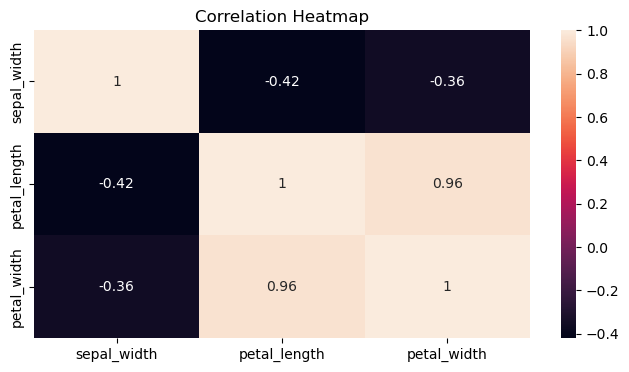

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
num_cols = ['sepal_width', 'petal_length', 'petal_width']

for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')
corr_matrix = data[num_cols].corr()
print(corr_matrix)

plt.figure(figsize=(8, 4))
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Heatmap')
plt.show()

Feature Engineering & Data Pre-processing

In [52]:
# Encode the categorical columns
# Create a LabelEncoder object
le = LabelEncoder()

# Encode the 'Species' column to convert the species names to numerical labels
data['species'] = le.fit_transform(data['species'])

# Check the unique values in the 'Species' column after encoding
unique_species = data['species'].unique()

# Display the unique encoded values
print("Encoded Species Values:")
print(unique_species) # 'Iris-setosa' == 0, 'Iris-versicolor' == 1, 'Iris-virginica' == 2

Encoded Species Values:
[0 1 2 4 3]


2. Data Scaling

In [53]:
# Defining the X and y
x=data.drop(columns=['species'], axis=1)
y=data['species']
     

3. Data Splitting

In [54]:
# Splitting the data to train and test
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.3)

In [55]:
# Checking the train distribution of dependent variable
y_train.value_counts()

species
2    78
0    68
1    65
Name: count, dtype: int64

6. ML Model Implementation


In [56]:
def evaluate_model(model, x_train, x_test, y_train, y_test):
    '''The function will take model, x train, x test, y train, y test
    and then it will fit the model, then make predictions on the trained model,
    it will then print roc-auc score of train and test, then plot the roc, auc curve,
    print confusion matrix for train and test, then print classification report for train and test,
    then plot the feature importances if the model has feature importances,
    and finally it will return the following scores as a list:
    recall_train, recall_test, acc_train, acc_test, F1_train, F1_test
    '''

    # Fit the model to the training data.
    model.fit(x_train, y_train)

    # make predictions on the test data
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    # calculate confusion matrix
    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_test = confusion_matrix(y_test, y_pred_test)

    fig, ax = plt.subplots(1, 2, figsize=(11,4))

    print("\nConfusion Matrix:")
    sns.heatmap(cm_train, annot=True, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], cmap="Oranges", fmt='.4g', ax=ax[0])
    ax[0].set_xlabel("Predicted Label")
    ax[0].set_ylabel("True Label")
    ax[0].set_title("Train Confusion Matrix")

    sns.heatmap(cm_test, annot=True, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], cmap="Oranges", fmt='.4g', ax=ax[1])
    ax[1].set_xlabel("Predicted Label")
    ax[1].set_ylabel("True Label")
    ax[1].set_title("Test Confusion Matrix")

    plt.tight_layout()
    plt.show()


    # calculate classification report
    cr_train = classification_report(y_train, y_pred_train, output_dict=True)
    cr_test = classification_report(y_test, y_pred_test, output_dict=True)
    print("\nTrain Classification Report:")
    crt = pd.DataFrame(cr_train).T
    print(crt.to_markdown())
    # sns.heatmap(pd.DataFrame(cr_train).T.iloc[:, :-1], annot=True, cmap="Blues")
    print("\nTest Classification Report:")
    crt2 = pd.DataFrame(cr_test).T
    print(crt2.to_markdown())
    # sns.heatmap(pd.DataFrame(cr_test).T.iloc[:, :-1], annot=True, cmap="Blues")

    precision_train = cr_train['weighted avg']['precision']
    precision_test = cr_test['weighted avg']['precision']

    recall_train = cr_train['weighted avg']['recall']
    recall_test = cr_test['weighted avg']['recall']

    acc_train = accuracy_score(y_true = y_train, y_pred = y_pred_train)
    acc_test = accuracy_score(y_true = y_test, y_pred = y_pred_test)

    F1_train = cr_train['weighted avg']['f1-score']
    F1_test = cr_test['weighted avg']['f1-score']

    model_score = [precision_train, precision_test, recall_train, recall_test, acc_train, acc_test, F1_train, F1_test ]
    return model_score
     


In [57]:
# Create a score dataframe
score = pd.DataFrame(index = ['Precision Train', 'Precision Test','Recall Train','Recall Test','Accuracy Train', 'Accuracy Test', 'F1 macro Train', 'F1 macro Test'])
     

ML Model - 1 : Logistic regression

In [58]:
# ML Model - 1 Implementation
lr_model = LogisticRegression(fit_intercept=True, max_iter=10000)

# Model is trained (fit) and predicted in the evaluate model
     

1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [60]:
# Visualizing evaluation Metric Score chart
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Impute missing values
imputer = SimpleImputer(strategy='mean')
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

# Train model
lr_model = LogisticRegression()
lr_model.fit(x_train, y_train)

# Predict
y_pred_test = lr_model.predict(x_test)


Confusion Matrix:


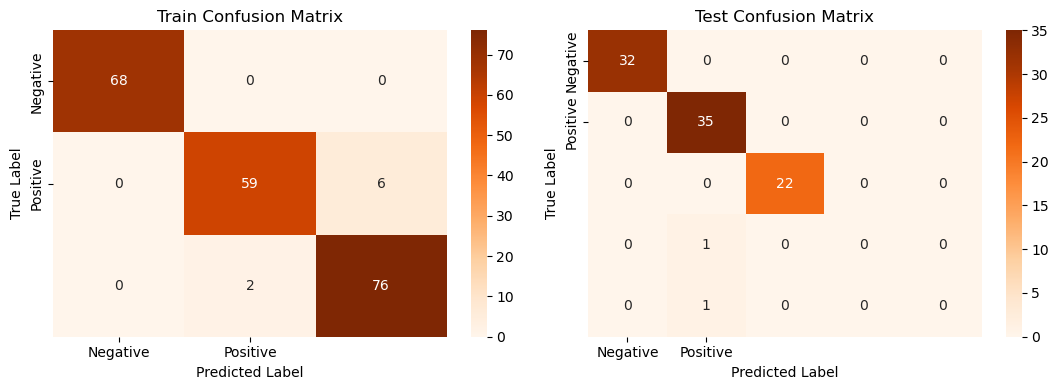


Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  68        |
| 1            |    0.967213 | 0.907692 |   0.936508 |  65        |
| 2            |    0.926829 | 0.974359 |   0.95     |  78        |
| accuracy     |    0.962085 | 0.962085 |   0.962085 |   0.962085 |
| macro avg    |    0.964681 | 0.960684 |   0.962169 | 211        |
| weighted avg |    0.962851 | 0.962085 |   0.961957 | 211        |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 32        |
| 1            |    0.945946 | 1        |   0.972222 | 35        |
| 2            |    1        | 1        |   1        | 22        |
| 3            |    0        | 0        |   0        |  1     

In [62]:

# Visualizing evaluation Metric Score chart
lr_score = evaluate_model(lr_model, x_train, x_test, y_train, y_test)

2. Cross- Validation & Hyperparameter Tuning

In [63]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Define the hyperparameter grid
param_grid = {'C': [100,10,1,0.1,0.01,0.001,0.0001],
              'penalty': ['l1', 'l2'],
              'solver':['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

# Initializing the logistic regression model
logreg = LogisticRegression(fit_intercept=True, max_iter=10000, random_state=0)

# Repeated stratified kfold
rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=4, random_state=0)

# Using GridSearchCV to tune the hyperparameters using cross-validation
grid = GridSearchCV(logreg, param_grid, cv=rskf)
grid.fit(x_train, y_train)

# Select the best hyperparameters found by GridSearchCV
best_params = grid.best_params_
print("Best hyperparameters: ", best_params)

Best hyperparameters:  {'C': 1, 'penalty': 'l2', 'solver': 'newton-cg'}


In [70]:
# Initiate model with best parameters
lr_model2 = LogisticRegression(C=best_params['C'],
                                  penalty=best_params['penalty'],
                                  solver=best_params['solver'],
                                  max_iter=10000, random_state=0)
     

In [71]:
# Updated Evaluation metric Score Chart
score['Logistic regression'] = lr_score
score
     

,Decision Tree,Logistic regression
Precision Train,1.000000,0.962851
Precision Test,0.957232,0.957232
Recall Train,1.000000,0.962085
Recall Test,0.978022,0.978022
Accuracy Train,1.000000,0.962085
Accuracy Test,0.978022,0.978022
F1 macro Train,1.000000,0.961957
F1 macro Test,0.967338,0.967338


Which hyperparameter optimization technique have i used and why?
The hyperparameter optimization technique used is GridSearchCV. GridSearchCV is a method that performs an exhaustive search over a specified parameter grid to find the best hyperparameters for a model. It is a popular method for hyperparameter tuning because it is simple to implement and can be effective in finding good hyperparameters for a model.

The choice of hyperparameter optimization technique depends on various factors such as the size of the parameter space, the computational resources available, and the time constraints. GridSearchCV can be a good choice when the parameter space is relatively small and computational resources are not a major concern

ML Model - 2 : Decision Tree

In [67]:

# ML Model - 2 Implementation
dt_model = DecisionTreeClassifier(random_state=20)

# Model is trained (fit) and predicted in the evaluate model

1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.


Confusion Matrix:


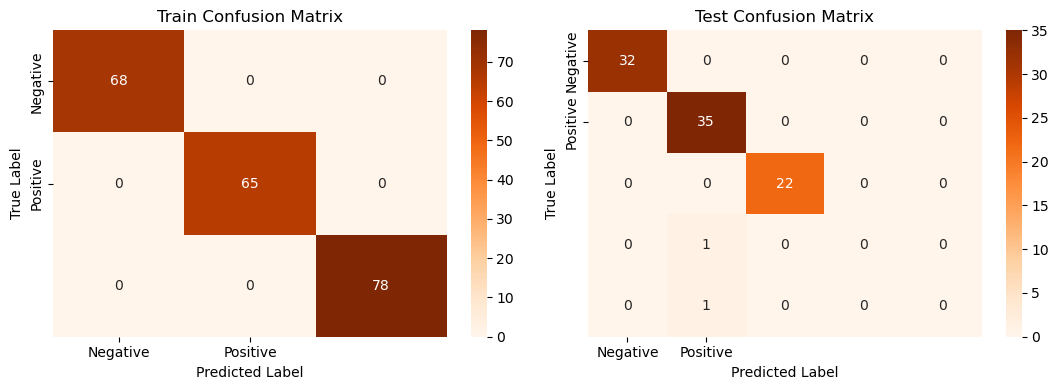


Train Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        68 |
| 1            |           1 |        1 |          1 |        65 |
| 2            |           1 |        1 |          1 |        78 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |           1 |        1 |          1 |       211 |
| weighted avg |           1 |        1 |          1 |       211 |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 32        |
| 1            |    0.945946 | 1        |   0.972222 | 35        |
| 2            |    1        | 1        |   1        | 22        |
| 3            |    0        | 0        |   0        |  1        |
| 4

In [68]:
# Visualizing evaluation Metric Score chart
dt_score = evaluate_model(dt_model, x_train, x_test, y_train, y_test)

In [69]:
# Updated Evaluation metric Score Chart
score['Decision Tree'] = dt_score
score
     

,Decision Tree
Precision Train,1.000000
Precision Test,0.957232
Recall Train,1.000000
Recall Test,0.978022
Accuracy Train,1.000000
Accuracy Test,0.978022
F1 macro Train,1.000000
F1 macro Test,0.967338


Conclusion
In the Iris flower classification project, the tuned Random Forest model has been selected as the final prediction model. The project aimed to classify Iris flowers into three distinct species: Iris-Setosa, Iris-Versicolor, and Iris-Virginica. After extensive data exploration, preprocessing, and model evaluation, the following conclusions can be drawn:

Data Exploration: Through a thorough examination of the dataset, we gained insights into the characteristics and distributions of features. We found that Iris-Setosa exhibited distinct features compared to the other two species.

Data Preprocessing: Data preprocessing steps, including handling missing values and encoding categorical variables, were performed to prepare the dataset for modeling.

Model Selection: After experimenting with various machine learning models, tuned Random Forest was chosen as the final model due to its simplicity, interpretability, and good performance in classifying Iris species.

Model Training and Evaluation: The Random Forest (tuned) model was trained on the training dataset and evaluated using appropriate metrics. The model demonstrated satisfactory accuracy and precision in classifying Iris species.

Challenges and Future Work: The project encountered challenges related to feature engineering and model fine-tuning. Future work may involve exploring more advanced modeling techniques to improve classification accuracy further.

Practical Application: The Iris flower classification model can be applied in real-world scenarios, such as botany and horticulture, to automate the identification of Iris species based on physical characteristics.

In conclusion, the Iris flower classification project successfully employed Random Forest (tuned) as the final prediction model to classify Iris species. The project's outcomes have practical implications in the field of botany and offer valuable insights into feature importance for species differentiation. Further refinements and enhancements may lead to even more accurate and reliable classification models in the future.